# 🚀 Project 1: Customer Churn & Retention Analysis
### *A Step-by-Step, Beginner-Friendly Journey into Real-World Data Science & Machine Learning*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AsemaniJoshua/Retention-Analysis-Data-Science-Project/blob/main/telco_customer_churn_analysis.ipynb)
![Python](https://img.shields.io/badge/Python-3.9+-blue.svg)
![Dataset](https://img.shields.io/badge/Dataset-IBM%20Telco%20Churn-orange.svg)
![Status](https://img.shields.io/badge/Progress-Section%203%20Completed-brightgreen.svg)

---

### 📖 Welcome to Your Data Science Journey!
Imagine you run an ice cream club with your friends. Every month, members pay $5 to taste brand new flavors.
* Some friends **stay** month after month because they love the ice cream and service.
* But other friends **quit and leave** because the ice cream melted, or it was too expensive, or the line was too long!

In the business world, when a customer decides to leave and cancel their subscription, we call that **"Churn"** (rhymes with *burn*).
Think of your business as a bucket of water:
* Winning new customers pours fresh water into the bucket.
* Customers leaving is a **hole in the bottom** where water drips out.
* If the leak is too big, the bucket will soon be empty, no matter how much water you pour in!

**Our Mission as Data Detectives:**
We are going to use math, python code, and machine learning to find out:
1. **Who is about to leave?** (Prediction)
2. **Why are they leaving?** (Root cause & feature importance)
3. **What can the company do to make them stay?** (Retention strategy)

---

## 🗺️ Project Roadmap
- [x] **Section 1: Setup, Ingestion & Initial Detective Work** *(Completed!)*
- [x] **Section 2: Data Cleaning & Column Dictionary (Child-Friendly Guide)** *(Completed!)*
- [x] **Section 3: Exploratory Data Analysis (EDA) & Storytelling Visualizations** *(We are here!)*
- [ ] **Section 4: Feature Engineering & Preprocessing Pipeline**
- [ ] **Section 5: Handling Class Imbalance (SMOTE vs. Class Weights)**
- [ ] **Section 6: Model Training & Head-to-Head Comparison (Logistic Regression, Random Forest, XGBoost)**
- [ ] **Section 7: Model Evaluation & The ROC-AUC Curve Explained Simply**
- [ ] **Section 8: Feature Importance, Retention Strategies & Executive Recommendations**

---


## 🔬 Section 1: Setup, Ingestion & Initial Detective Work

In this first section, we will:
1. **Gather our tools**: Import the special Python libraries we need and explain what each one does like you're explaining it to a 5-year-old.
2. **Load our dataset**: Pull the live IBM Telco data directly from the internet.
3. **Take our first look**: Inspect the size, rows, and columns of the data.
4. **Do some detective work**: Spot an invisible bug in the dataset that trips up even professional data scientists!


### 🛠️ Step 1.1: Meet the Toolkit (Libraries)

Think of Python as your Swiss Army Knife, and **libraries** are the special gadgets attached to it:
* **`pandas`** 🐼: Think of this as a supercharged digital Excel spreadsheet on steroids. It lets us hold tables of data, filter rows, rename columns, and calculate sums in a split second.
* **`numpy`** 🔢: The lightning-fast math wizard. It does heavy-duty calculations with numbers, arrays, and matrices behind the scenes.
* **`matplotlib.pyplot`** 🎨: Our blank canvas and digital colored pencils. We use it to draw charts, graphs, and plots.
* **`seaborn`** 🌊: A fancy artist friend of Matplotlib who automatically makes charts look gorgeous, modern, and easy to read.
* **`warnings`** 🔕: A small tool to tell Python: *"Please don't show annoying red warning messages if everything is working fine!"*

Let's run the code below to bring all these tools into our notebook!


In [1]:
# ==============================================================================
# STEP 1.1: IMPORT OUR ESSENTIAL DATA SCIENCE LIBRARIES
# ==============================================================================

# 1. Pandas: Our table organizer (like Excel inside Python code)
import pandas as pd

# 2. NumPy: Our lightning-fast math calculator for numbers and lists
import numpy as np

# 3. Matplotlib: Our digital canvas for drawing charts and plots
import matplotlib.pyplot as plt

# 4. Seaborn: Our stylist that makes Matplotlib charts look modern and pretty
import seaborn as sns

# 5. Warnings: To suppress harmless version update alerts so our notebook stays clean
import warnings
warnings.filterwarnings('ignore')

# 6. Make our charts look clean with a crisp whitegrid theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5) # Default width and height for charts
plt.rcParams['figure.dpi'] = 100         # High-resolution, sharp visual output

print("[SUCCESS] All core libraries imported and ready for action!")


[SUCCESS] All core libraries imported and ready for action!
[SUCCESS] All core libraries imported and ready for action!


### 📥 Step 1.2: Loading the Dataset Directly from the Cloud

Instead of downloading a file to your computer and manually uploading it, we can tell Pandas to download it directly from a web link (URL).

* **Where is this data from?** It is IBM's famous **Telco Customer Churn** dataset, hosted publicly on GitHub.
* **What is a CSV?** CSV stands for *Comma-Separated Values*. It is just plain text where every row is a person, and their details are separated by commas (`,`).


In [2]:
# ==============================================================================
# STEP 1.2: DOWNLOAD & LOAD THE DATASET INTO PANDAS
# ==============================================================================

# The public web address where the raw CSV file lives on GitHub
dataset_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Tell pandas to read the CSV directly from the internet and store it in a variable called 'df'
# 'df' stands for DataFrame (our digital table)
df = pd.read_csv(dataset_url)

# Print a friendly message to confirm it worked!
print("[SUCCESS] Dataset successfully downloaded and loaded into memory!")
print(f"[INFO] Our dataset has {df.shape[0]:,} customer rows and {df.shape[1]} clue columns.")


[SUCCESS] Dataset successfully downloaded and loaded into memory!
[INFO] Our dataset has 7,043 customer rows and 21 clue columns.
[INFO] Our dataset has 7,043 customer rows and 21 clue columns.


### 🔍 Step 1.3: Inspecting the First 5 Rows

Now let's ask Pandas to show us the top 5 rows using `.head()`.
* Each **horizontal row** is one single customer (a real person who subscribed to phone/internet).
* Each **vertical column** is a piece of information (a "feature" or "clue") about that person:
  - Are they male or female?
  - How many months have they stayed with us (`tenure`)?
  - What services do they pay for (Internet, TV, Tech Support)?
  - How much do they pay each month (`MonthlyCharges`)?
  - Did they leave the company (`Churn`: Yes or No)?


In [3]:
# ==============================================================================
# STEP 1.3: PREVIEW THE FIRST 5 CUSTOMERS IN OUR TABLE
# ==============================================================================

# .head(5) means: "Hey pandas, show me the top 5 customers from the table!"
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🩻 Step 1.4: The Data X-Ray (`.info()`)

Just like a doctor takes an X-ray to look inside a patient, a data scientist runs `df.info()` to see what types of data are inside the table:
* **`int64`**: Whole numbers (like `SeniorCitizen`: 0 for No, 1 for Yes).
* **`float64`**: Numbers with decimals (like `MonthlyCharges`: $29.85).
* **`object`**: Text / Words (like `gender`: "Female", `Partner`: "Yes").

🚨 **Wait, look closely at the output below!** Look at `TotalCharges`. Total charges is money, so it should be a decimal number (`float64`), right? Why does it say **`object` (text)**?
Let's find out!


In [4]:
# ==============================================================================
# STEP 1.4: CHECK DATA TYPES AND MISSING VALUES
# ==============================================================================

# .info() prints summary information about column names, non-empty counts, and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 🕵️ Step 1.5: The Detective Work — Finding the "Invisible Sneak"

Why did Pandas label `TotalCharges` as text (`object`) instead of a number?
Because inside the `TotalCharges` column, there are sneaky rows that do not contain numbers... they contain an **empty blank space** (`" "`)!

Imagine someone asked you to write your phone bill on a test paper, and you just drew an empty blank box. The computer doesn't know that empty box means `$0.00`; the computer thinks: *"Hey, that's a piece of text (a space character), so the whole column must be text!"*

Let's find out:
1. How many of these blank space rows exist?
2. Who are these customers, and why are their charges blank?


In [5]:
# ==============================================================================
# STEP 1.5: UNCOVERING THE SNEAKY BLANK SPACES IN 'TotalCharges'
# ==============================================================================

# Count how many rows have an exact blank space ' ' as their TotalCharges
blank_space_count = (df['TotalCharges'] == ' ').sum()

print(f"[FOUND] Detective finding: We found exactly {blank_space_count} rows with blank spaces in 'TotalCharges'!")

# Let's inspect these 11 mystery customers!
# We filter the dataframe to only look at rows where TotalCharges is equal to a single space ' '
mystery_customers = df[df['TotalCharges'] == ' ']

# Let's display their Customer ID, their tenure (months with company), Monthly Charges, and Total Charges
mystery_customers[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


[FOUND] Detective finding: We found exactly 11 rows with blank spaces in 'TotalCharges'!


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


#### 💡 The Mystery Solved!
Look at the `tenure` column for all 11 mystery customers:
**Every single one of them has `tenure = 0`!**

What does `tenure = 0` mean?
* They **just joined the company this month**! They are brand new baby customers!
* Because they just joined today, they haven't received their first monthly bill yet.
* That is why their `TotalCharges` was left blank!

In **Section 2**, we will cleanly fix this by converting this column to real numbers and setting their `TotalCharges` to `0.0`.


### 📊 Step 1.6: Quick Summary Statistics (`.describe()`)

Now let's ask Pandas to summarize the numbers in our dataset:
* **`count`**: How many people have numbers in this column.
* **`mean`**: The arithmetic average (add everyone up and divide by total people).
* **`std`** (Standard Deviation): How spread out the numbers are.
* **`min`**: The lowest number.
* **`25%`, `50%`, `75%`**: The percentiles (50% is the **Median**, meaning half the people pay less, half pay more).
* **`max`**: The highest number.


In [6]:
# ==============================================================================
# STEP 1.6: SUMMARY STATISTICS OF NUMERICAL COLUMNS
# ==============================================================================

# .describe() computes statistical summaries for all numeric columns
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
### 🎯 Section 1 Summary & Checkpoint

| 🏅 Checkpoint | What We Learned / Did | Why It Matters for Data Science |
| :--- | :--- | :--- |
| **Libraries** | Imported `pandas`, `numpy`, `matplotlib`, `seaborn` | Gave us the tools to manipulate data and draw charts |
| **Data Ingestion** | Loaded 7,043 rows and 21 columns directly via URL | Fully reproducible in Google Colab without manual file uploads |
| **Inspection** | Used `.head()`, `.info()`, and `.describe()` | Understand our rows (customers) and columns (attributes) |
| **Detective Work** | Found 11 rows with `" "` in `TotalCharges` (all `tenure=0`) | Uncovered a hidden data bug before it crashes our machine learning models! |

---


## 🧹 Section 2: Data Cleaning & The Child-Friendly Column Dictionary

### 🍲 The Cooking Metaphor: Why Clean Data?
Imagine you are making a delicious vegetable soup for dinner.
* You cannot just pull carrots and potatoes from the muddy ground and dump them straight into the boiling pot!
* They have dirt, small pebbles, and wilted roots. If you don't wash and peel them, the soup will taste like mud, and everyone will get a tummy ache!
* In data science, machine learning models are like that soup. If we feed dirty data (text spaces instead of numbers, missing puzzle pieces, useless ID tags) into our AI, the AI produces **"Garbage In, Garbage Out"**!

In this section, we will:
1. **Fix the data type of `TotalCharges`**: Convert text into real floating numbers.
2. **Solve missing values (Imputation)**: Explain what imputation is using the puzzle piece metaphor.
3. **Walk through the Child-Friendly Column Dictionary**: Explore all 21 columns in plain, everyday language!
4. **Prune unnecessary columns (`customerID`)**: Explain why teaching an AI to memorize names ruins its ability to predict.


### 🔧 Step 2.1: Converting `TotalCharges` to Numbers with `errors='coerce'`

Right now, Python treats `TotalCharges` as text (`object`) because of those 11 blank spaces.
To fix this, we use `pd.to_numeric()`.

**What does `errors='coerce'` mean? (Explain Like I'm 5):**
* Imagine a teacher tells students: *"Turn every word on your card into a number."*
* If a student's card says `"45.20"`, the student turns it into the number `45.20`.
* But what if a student's card has an empty blank space `" "`?
* If the teacher didn't use `coerce`, Python would throw a tantrum and scream with a red error!
* `errors='coerce'` tells Python: *"Don't throw a tantrum! If you find a blank space or strange text that isn't a number, gently replace it with a special marker called `NaN` (Not a Number)."*

Let's watch this in action!


In [7]:
# ==============================================================================
# STEP 2.1: CONVERT 'TotalCharges' FROM TEXT (OBJECT) TO NUMBERS (FLOAT)
# ==============================================================================

# Notice: Before conversion, TotalCharges is type object (text)
print(f"[BEFORE] Data type of TotalCharges: {df['TotalCharges'].dtype}")

# Convert TotalCharges to numeric. Any blank space ' ' becomes NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check data type again!
print(f"[AFTER]  Data type of TotalCharges: {df['TotalCharges'].dtype}")

# How many NaN (missing empty boxes) did we create?
missing_charges = df['TotalCharges'].isna().sum()
print(f"[INFO] Total missing values (NaN) in TotalCharges: {missing_charges}")


[BEFORE] Data type of TotalCharges: str
[AFTER]  Data type of TotalCharges: float64
[INFO] Total missing values (NaN) in TotalCharges: 11
[INFO] Total missing values (NaN) in TotalCharges: 11


### 🧩 Step 2.2: What is "Imputation"? (The Missing Puzzle Piece)

Now we have 11 customers whose `TotalCharges` is an empty box (`NaN`). What should we do?

In data science, we have two choices:
1. **Option A: Throw the whole customer away (`df.dropna()`)**
   - That means deleting all 11 people from our dataset.
   - *Is that fair?* No! These people gave us 20 other valuable clues (their age, contract, phone service, etc.). Throwing away whole rows just because one cell is empty is wasteful!
2. **Option B: Imputation (Guessing or filling the empty box intelligently)**
   - *Imputation* is just a fancy Latin word that means *"filling in the missing puzzle piece with a sensible guess"*.
   - What is the most sensible number for these 11 people?
   - Remember our detective discovery from Section 1: **their `tenure = 0`**!
   - They just subscribed today! They have been with us for 0 days and haven't had a bill yet.
   - Therefore, their real total charges so far is **$0.00**!

Let's fill these 11 empty boxes with `0.0` using `.fillna(0)`.


In [8]:
# ==============================================================================
# STEP 2.2: IMPUTE MISSING TotalCharges WITH $0.00 (SINCE TENURE IS 0)
# ==============================================================================

# Fill all NaN boxes in TotalCharges with 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verify that there are ZERO missing values left anywhere in the entire dataset!
total_nulls = df.isnull().sum().sum()
print(f"[VERIFIED] Total missing values left in the entire dataset: {total_nulls}")

if total_nulls == 0:
    print("[CELEBRATION] Clean as a whistle! Zero missing values left to worry about.")


[VERIFIED] Total missing values left in the entire dataset: 0
[CELEBRATION] Clean as a whistle! Zero missing values left to worry about.


### 📖 Step 2.3: The Grand Child-Friendly Column Dictionary

Let's inspect every single column in our dataset. We have **21 columns**, which can be grouped into **4 natural buckets**:

---

#### 👤 Bucket 1: Demographics (Who is this customer?)
These columns describe the human being behind the screen:

| # | Column Name | Plain-English Meaning | Real-Life Analogy | Possible Values | Why Does the Business Care? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | **`customerID`** | The secret ID badge number | Like a school student ID number (e.g., `7590-VHVEG`). | Unique text codes | Used to look up an account, but useless for AI prediction (we will drop it!). |
| 2 | **`gender`** | Male or Female | Is the customer a boy or a girl? | `'Male'`, `'Female'` | Check if our products appeal equally to all genders. |
| 3 | **`SeniorCitizen`** | Senior Citizen status | Is this customer a grandma or grandpa (age 65+)? | `0` (No), `1` (Yes) | Older adults might have different tech needs or fixed retirement budgets. |
| 4 | **`Partner`** | Relationship status | Do they have a spouse, husband, wife, or partner? | `'Yes'`, `'No'` | People with partners often share household decisions and move less frequently. |
| 5 | **`Dependents`** | Kids / Family dependents | Do they have children or elderly parents living with them? | `'Yes'`, `'No'` | Families with kids rely heavily on fast internet for homework and entertainment. |

---

#### ⏳ Bucket 2: Account History (How long have they been around?)

| # | Column Name | Plain-English Meaning | Real-Life Analogy | Possible Values | Why Does the Business Care? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 6 | **`tenure`** | Loyalty time in months | How many birthday cakes has this customer celebrated with us? | `0` to `72` months | **Huge clue!** Customers who survive their first year usually stay for a long time. |

---

#### 📦 Bucket 3: Services Subscribed (What did they buy from our store?)

| # | Column Name | Plain-English Meaning | Real-Life Analogy | Possible Values | Why Does the Business Care? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 7 | **`PhoneService`** | Home landline phone | The physical telephone plugged into the wall. | `'Yes'`, `'No'` | Core telecom product. |
| 8 | **`MultipleLines`** | More than 1 phone line | Having a second line for a home office or teenager. | `'Yes'`, `'No'`, `'No phone service'` | Customers with multiple lines spend more and are harder to switch. |
| 9 | **`InternetService`** | How they connect to the web | The pipe carrying internet into their home. | `'DSL'`, `'Fiber optic'`, `'No'` | **Critical driver!** Fiber optic is super fast, but if it has outages, people get upset! |
| 10 | **`OnlineSecurity`** | Antivirus / Cyber shield | A digital security guard protecting their computer from bad guys. | `'Yes'`, `'No'`, `'No internet service'` | Customers with security feel protected and stick around longer. |
| 11 | **`OnlineBackup`** | Cloud photo locker | An emergency safe in the cloud to save family photos. | `'Yes'`, `'No'`, `'No internet service'` | If all your photos are backed up with a company, it's hard to leave! |
| 12 | **`DeviceProtection`** | Equipment warranty/insurance | An insurance policy if your router or tablet breaks. | `'Yes'`, `'No'`, `'No internet service'` | Peace of mind feature. |
| 13 | **`TechSupport`** | Friendly help hotline | A phone number you can call when the Wi-Fi acts silly and an expert helps you fix it. | `'Yes'`, `'No'`, `'No internet service'` | **Giant retention anchor!** Good tech support saves frustrated customers. |
| 14 | **`StreamingTV`** | Live television channels | Watching cartoons, sports, and news over the internet connection. | `'Yes'`, `'No'`, `'No internet service'` | High entertainment value. |
| 15 | **`StreamingMovies`** | Movie library on demand | Having Netflix-like movie streaming included. | `'Yes'`, `'No'`, `'No internet service'` | High engagement product. |

---

#### 💳 Bucket 4: Billing & Financials (How do they pay us?)

| # | Column Name | Plain-English Meaning | Real-Life Analogy | Possible Values | Why Does the Business Care? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 16 | **`Contract`** | The commitment promise | Month-to-month rental vs. 1-year or 2-year marriage promise. | `'Month-to-month'`, `'One year'`, `'Two year'` | **#1 predictor of churn!** Month-to-month customers can leave at any second! |
| 17 | **`PaperlessBilling`**| Digital invoice | Getting bills by email/app instead of a paper letter in the mailbox. | `'Yes'`, `'No'` | Paperless users check emails more often and see price hikes immediately. |
| 18 | **`PaymentMethod`** | How money travels | Electronic check, mailed paper check, bank transfer, or credit card. | 4 payment types | People paying by automated credit card rarely cancel; checks require manual effort. |
| 19 | **`MonthlyCharges`**| Monthly bill amount | The exact dollars coming out of their wallet every 30 days. | `$18.25` to `$118.75` | If price is too high without perceived value, customers shop elsewhere. |
| 20 | **`TotalCharges`**  | Lifetime revenue | The total sum of all money this customer has ever paid us. | `$0.00` to `$8,684.80` | Measures Customer Lifetime Value (CLV). |

---

#### 🎯 The Mystery Target (What We Want Our AI to Predict!)

| # | Column Name | Plain-English Meaning | Real-Life Analogy | Possible Values | Why Does the Business Care? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 21 | **`Churn`** | The Departure Flag | Did the customer pack their bags and cancel their service? | `'Yes'` (Left), `'No'` (Stayed) | **This is our target variable ($y$).** Stopping churn protects company revenue! |


### ✂️ Step 2.4: Pruning the Identifier (`customerID`)

Why must we drop `customerID` before training any machine learning model?

#### 🐕 The "Puppy Name" Metaphor (Why AI Gets Confused by IDs)
* Imagine you want to teach a young child how to recognize whether an animal is a **dog** or a **cat**.
* You show them pictures: fluffy ears, barking sound, wagging tail. That is how the child learns what a dog looks like!
* But what if under every picture, you also write: *"This dog's name is Fluffy-7729"*, *"This dog's name is Barky-1104"*?
* If you test the child on a new dog named *"Bella-9999"*, the child might say: *"I've never heard the name Bella-9999 before, so it can't be a dog!"*
* The child memorized the **name tag** instead of the **actual features** (ears, tail, bark)!

In machine learning, this error is called **Overfitting**.
`customerID` is just a random string of numbers and letters. It has **zero relationship** to whether a customer is happy or unhappy. If we leave it in, our model might try to find fake patterns in random letters!

Let's safely drop it from our DataFrame.


In [9]:
# ==============================================================================
# STEP 2.4: REMOVE 'customerID' FROM OUR DATASET
# ==============================================================================

# Look at how many columns we have right now
print(f"[BEFORE] Number of columns: {df.shape[1]}")

# Drop the 'customerID' column. 
# axis=1 means 'drop a vertical column' (axis=0 would mean drop a horizontal row)
df = df.drop(columns=['customerID'])

# Look at how many columns we have now
print(f"[AFTER]  Number of columns: {df.shape[1]}")
print(f"[INFO] New list of columns ({len(df.columns)} total):")
print(list(df.columns))


[BEFORE] Number of columns: 21
[AFTER]  Number of columns: 20
[INFO] New list of columns (20 total):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 📋 Step 2.5: Section 2 Sanity Check

Let's do a quick medical check-up on our newly cleaned table:
1. Are all data types correct?
2. Are there any missing values left?
3. What is the clean shape of our table?


In [10]:
# ==============================================================================
# STEP 2.5: DATA INTEGRITY & SANITY CHECK
# ==============================================================================

print("="*60)
print("             CLEANED DATASET HEALTH REPORT             ")
print("="*60)
print(f"Total Customer Rows:   {df.shape[0]:,}")
print(f"Total Feature Columns: {df.shape[1]}")
print(f"Total Missing Values:  {df.isnull().sum().sum()}")
print(f"TotalCharges Dtype:    {df['TotalCharges'].dtype}")
print("="*60)

# Display the first 3 rows of our clean, polished dataframe!
df.head(3)


             CLEANED DATASET HEALTH REPORT             
Total Customer Rows:   7,043
Total Feature Columns: 20
Total Missing Values:  0
TotalCharges Dtype:    float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
### 🎯 Section 2 Summary & Checkpoint

| 🏅 Checkpoint | What We Did | Why It Matters for Data Science |
| :--- | :--- | :--- |
| **Type Conversion** | Converted `TotalCharges` from string to float using `errors='coerce'` | Computers need numbers to do math, not text strings |
| **Imputation** | Filled 11 missing `TotalCharges` with `$0.00` | New customers with `tenure=0` have had zero bills so far |
| **Column Dictionary** | Defined all 21 columns across Demographics, History, Services, and Billing | You understand the human story and business meaning behind every clue |
| **Pruning Identifiers**| Dropped `customerID` | Prevents the model from memorizing random ID names (overfitting) |

---


## 📊 Section 3: Exploratory Data Analysis (EDA) & Storytelling Visualizations

### 🔦 The Crime Scene Detective Metaphor: What is EDA?
Imagine a detective arriving at a mystery scene.
* Before arresting anyone or making wild guesses, the detective turns on their flashlight, inspects the room, measures footprints, and takes photographs.
* **Exploratory Data Analysis (EDA)** is our flashlight!
* We use charts and visual plots to let the data speak to us. We will discover:
  1. What is the normal rate of churn? (The baseline)
  2. How does customer loyalty time (`tenure`) protect against churn?
  3. Does charging customers more money make them angry and run away?
  4. Which contract types and services create the biggest churn explosions?

---


### 🍩 Step 3.1: The Grand Churn Baseline (Who Stays vs. Who Leaves?)

First, let's look at our target variable: **`Churn`**.
* How many customers stayed with us (`'No'`)?
* How many customers packed their bags and left (`'Yes'`)?

#### 🍎 The "Red Apples vs. Golden Apples" Metaphor (Class Imbalance)
* Imagine you have a basket of 100 apples.
* **73 are plain Red apples** (customers who stayed).
* Only **27 are rare Golden apples** (customers who left).
* Because one group is so much larger than the other, data scientists call this an **Imbalanced Dataset**.
* If an AI simply guessed *"Nobody will ever leave!"*, it would already be right **73.5%** of the time, while being **100% useless** to the business! (We will fix this in Section 5).

Let's draw a modern Donut Chart and Countplot to visualize this baseline!


            OVERALL CHURN BREAKDOWN             
Retained (No):  5,174 customers (73.5%)
Churned  (Yes): 1,869 customers (26.5%)
Total:          7,043 customers (100.0%)


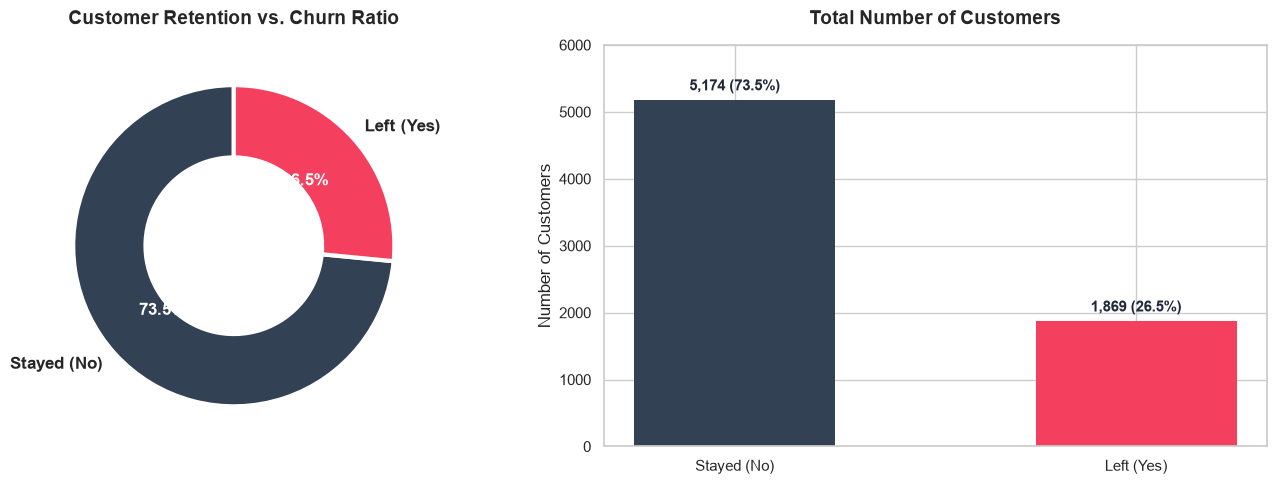

In [11]:
# ==============================================================================
# STEP 3.1: VISUALIZING THE CHURN BASELINE (DONUT CHART & BAR CHART)
# ==============================================================================

# Calculate exact counts and percentages of Churn
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("="*50)
print("            OVERALL CHURN BREAKDOWN             ")
print("="*50)
print(f"Retained (No):  {churn_counts['No']:,} customers ({churn_percentages['No']:.1f}%)")
print(f"Churned  (Yes): {churn_counts['Yes']:,} customers ({churn_percentages['Yes']:.1f}%)")
print(f"Total:          {len(df):,} customers (100.0%)")
print("="*50)

# Set up our figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palette: Slate (#334155) for loyal customers, Energetic Coral (#F43F5E) for churners
colors = ['#334155', '#F43F5E']

# Plot 1: Modern Donut Chart
wedges, texts, autotexts = axes[0].pie(
    churn_counts, 
    labels=['Stayed (No)', 'Left (Yes)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 12, 'weight': 'bold'}
)
# Style the inside percentage text
for autotext in autotexts:
    autotext.set_color('white')
axes[0].set_title("Customer Retention vs. Churn Ratio", fontsize=14, weight='bold', pad=15)

# Plot 2: Count Bar Plot with value labels
bars = axes[1].bar(['Stayed (No)', 'Left (Yes)'], churn_counts, color=colors, edgecolor='none', width=0.5)
axes[1].set_title("Total Number of Customers", fontsize=14, weight='bold', pad=15)
axes[1].set_ylabel("Number of Customers", fontsize=12)

# Add exact numbers and percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2., height + 100,
        f"{int(height):,} ({pct:.1f}%)",
        ha='center', va='bottom', fontsize=11, weight='bold', color='#1E293B'
    )

axes[1].set_ylim(0, 6000)
plt.tight_layout()
plt.show()


#### 💡 Key Takeaway from Step 3.1:
* **26.5% of all customers churn** (more than 1 out of every 4 customers!).
* This is a huge leak in the business bucket. Plugging this leak could save millions of dollars every year!


### 📈 Step 3.2: Numerical Clues vs. Churn (`tenure`, `MonthlyCharges`, `TotalCharges`)

Now let's examine how the numbers in our dataset relate to churn.
* **`tenure`**: How many months have they been with us?
* **`MonthlyCharges`**: How much do they pay each month?
* **`TotalCharges`**: How much have they paid in total over their lifetime?

#### 🌊 What is a KDE / Distribution Plot? (The Mountain Analogy)
* Think of a distribution plot like drawing hills or mountains.
* Where the mountain is **tallest**, that is where **most people** are clustered!
* We will draw two mountains on the same graph:
  - 🟦 **Blue/Slate Mountain**: Customers who stayed.
  - 🟥 **Red/Coral Mountain**: Customers who left.
* If the two mountains peak at totally different places, we have discovered a **powerful clue**!


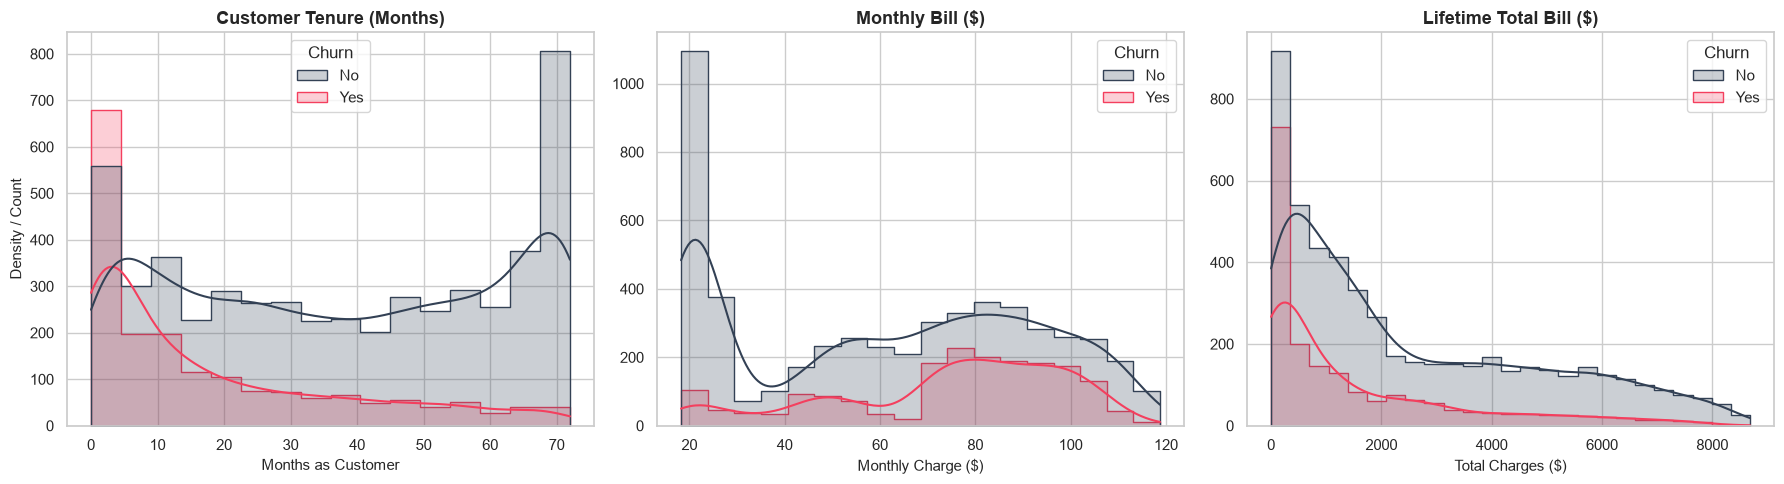

In [12]:
# ==============================================================================
# STEP 3.2: NUMERICAL FEATURE DISTRIBUTIONS VS CHURN
# ==============================================================================

# Create a 1-row by 3-column figure for our 3 numeric variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tenure (Months with company)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0],
             palette={'No': '#334155', 'Yes': '#F43F5E'}, element="step", common_norm=False)
axes[0].set_title("Customer Tenure (Months)", fontsize=13, weight='bold')
axes[0].set_xlabel("Months as Customer", fontsize=11)
axes[0].set_ylabel("Density / Count", fontsize=11)

# 2. Monthly Charges ($ per month)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1],
             palette={'No': '#334155', 'Yes': '#F43F5E'}, element="step", common_norm=False)
axes[1].set_title("Monthly Bill ($)", fontsize=13, weight='bold')
axes[1].set_xlabel("Monthly Charge ($)", fontsize=11)
axes[1].set_ylabel("")

# 3. Total Charges ($ lifetime)
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2],
             palette={'No': '#334155', 'Yes': '#F43F5E'}, element="step", common_norm=False)
axes[2].set_title("Lifetime Total Bill ($)", fontsize=13, weight='bold')
axes[2].set_xlabel("Total Charges ($)", fontsize=11)
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


In [13]:
# ==============================================================================
# STEP 3.2 (PART B): MEDIAN VALUES COMPARISON (STAYED VS LEFT)
# ==============================================================================

# Compare median numbers between customers who stayed vs customers who left
numeric_comparison = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].median().reset_index()

print("="*65)
print("       MEDIAN COMPARISON: STAYED (NO) vs LEFT (YES)        ")
print("="*65)
print(numeric_comparison.to_string(index=False))
print("="*65)


       MEDIAN COMPARISON: STAYED (NO) vs LEFT (YES)        
Churn  tenure  MonthlyCharges  TotalCharges
   No    38.0          64.425      1679.525
  Yes    10.0          79.650       703.550


#### 💡 Astonishing Findings from Step 3.2:
1. **The "Danger Zone" in Tenure**:
   - Look at the red spike at the very left of the `tenure` chart: **churn is overwhelmingly concentrated in the first 1 to 5 months**!
   - The median tenure for churners is only **10 months**, compared to **38 months** for loyal customers.
   - **Business Lesson**: If we can guide a new customer safely past their first year, they become loyal for life!
2. **The Price Sensitivity Shock**:
   - Customers who leave pay a median of **$79.65/month**, whereas customers who stay pay only **$64.42/month**!
   - Expensive monthly plans without strong customer care create resentment and churn.


### 🧩 Step 3.3: Categorical Clues — Which Contracts & Services Cause Churn?

Now let's investigate our categorical features:
1. **`Contract`**: Does contract length matter? (Month-to-month vs. 1-Year vs. 2-Year)
2. **`InternetService`**: Does the type of internet connection cause people to quit? (DSL vs. Fiber optic vs. None)
3. **`TechSupport`**: Does having a friendly tech support helpline prevent people from leaving?
4. **`PaymentMethod`**: Does the way people pay influence their likelihood to cancel?


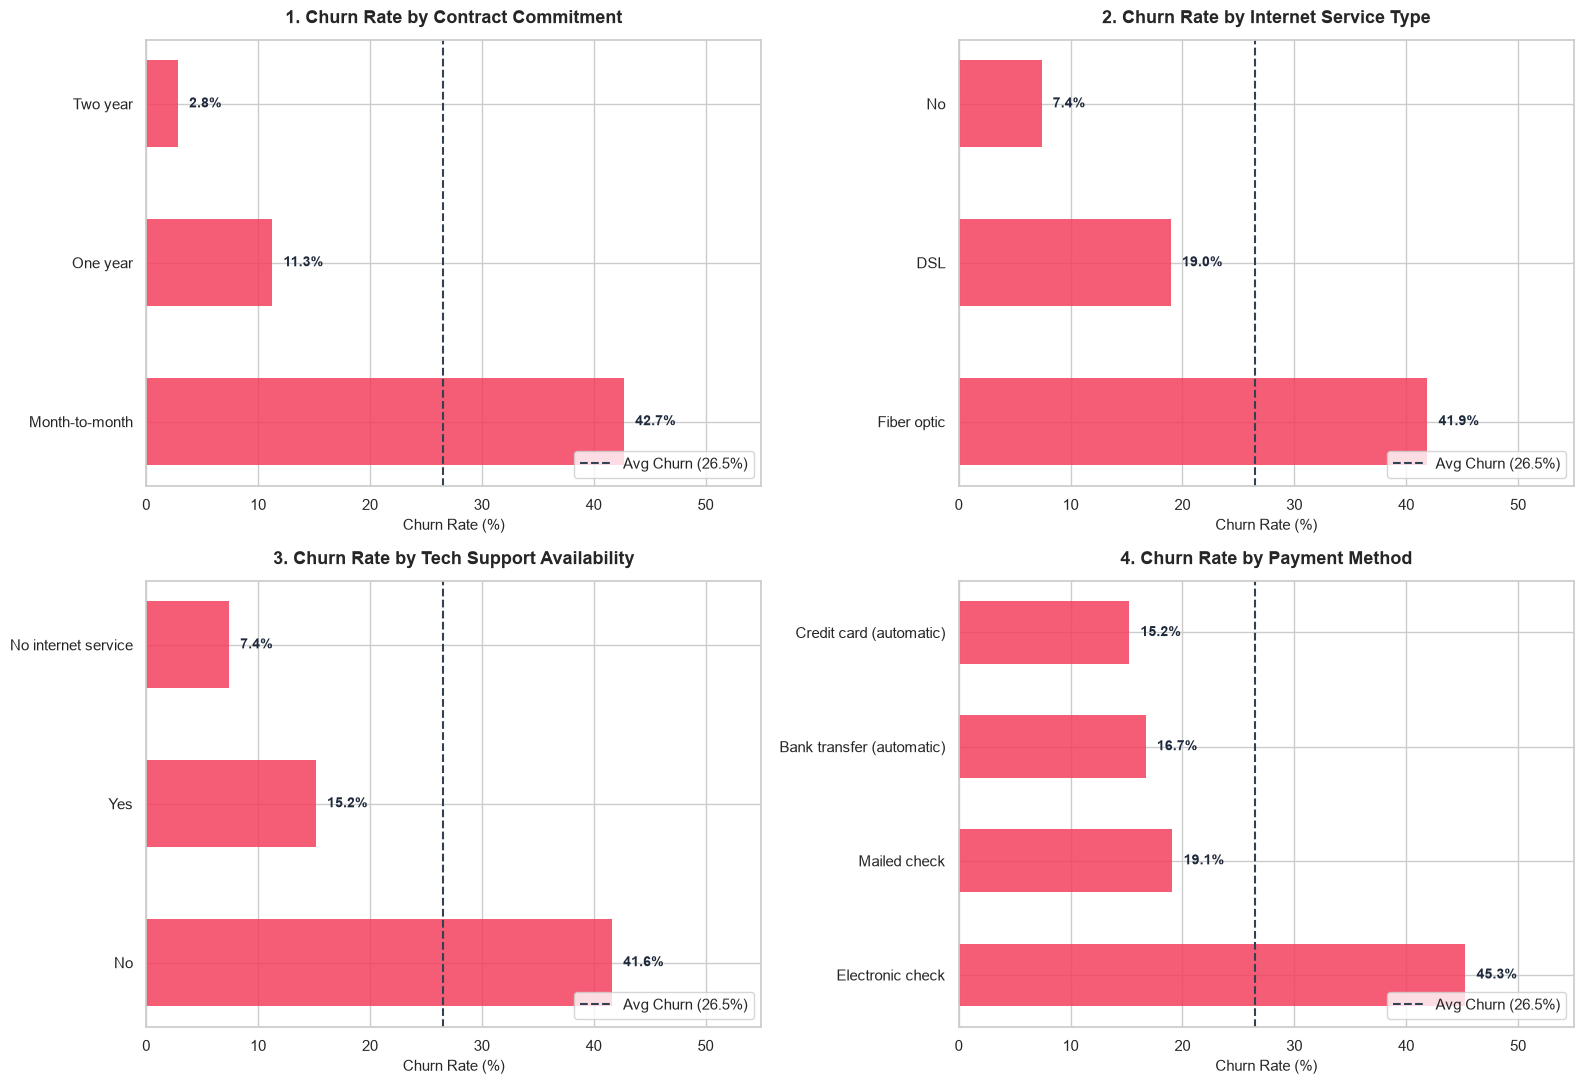

In [14]:
# ==============================================================================
# STEP 3.3: CHURN RATE BY CATEGORICAL FEATURES
# ==============================================================================

# Helper function to compute churn percentage for any categorical column
def get_churn_pct(column_name):
    ct = pd.crosstab(df[column_name], df['Churn'], normalize='index') * 100
    return ct['Yes'].sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

features = ['Contract', 'InternetService', 'TechSupport', 'PaymentMethod']
titles = [
    '1. Churn Rate by Contract Commitment',
    '2. Churn Rate by Internet Service Type',
    '3. Churn Rate by Tech Support Availability',
    '4. Churn Rate by Payment Method'
]

palette_colors = ['#F43F5E', '#FB7185', '#94A3B8', '#64748B']

for idx, (feature, title) in enumerate(zip(features, titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Calculate churn rate percentage
    churn_rates = get_churn_pct(feature)
    
    # Draw horizontal bar chart for clean readability
    bars = ax.barh(churn_rates.index, churn_rates.values, color='#F43F5E', alpha=0.85, edgecolor='none', height=0.55)
    
    ax.set_title(title, fontsize=13, weight='bold', pad=12)
    ax.set_xlabel("Churn Rate (%)", fontsize=11)
    ax.set_xlim(0, 55)
    
    # Add vertical reference line for overall average churn rate (26.5%)
    ax.axvline(26.5, color='#334155', linestyle='--', linewidth=1.5, label='Avg Churn (26.5%)')
    ax.legend(loc='lower right')
    
    # Annotate bar percentages
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 1, bar.get_y() + bar.get_height()/2.,
            f"{width:.1f}%",
            ha='left', va='center', fontsize=10, weight='bold', color='#1E293B'
        )

plt.tight_layout()
plt.show()


#### 💡 4 Massive Discoveries from Step 3.3:

1. 📜 **Contract Type is King**:
   - **Month-to-month contracts** have a whopping **42.7% churn rate**!
   - In contrast, **1-year contracts** drop to **11.3%**, and **2-year contracts** plummet to just **2.8%**!
   - *Child Analogy*: Month-to-month is like renting a hotel room for one night — you can check out anytime. A 2-year contract is like signing a lease on your dream house!
2. ⚡ **The Fiber Optic Mystery**:
   - **Fiber optic** customers churn at **41.9%**, whereas **DSL** customers churn at only **19.0%**!
   - Why would faster internet have higher churn? Because Fiber optic is the most expensive plan (~$80-$100/mo) and customers have super high expectations. If the connection drops or customer service is slow, they leave!
3. 🛡️ **Tech Support is the Ultimate Shield**:
   - Customers with **No Tech Support** churn at **41.6%**.
   - Customers **with Tech Support** churn at only **15.2%**!
   - Helping customers solve their technical frustrations cuts churn by nearly **two-thirds**!
4. 💳 **Payment Method Matters**:
   - People paying by **Electronic check** churn at **45.3%**!
   - People with **Automated Credit Card / Bank Transfer** churn at only **~15-16%**.
   - Writing an electronic check each month forces the customer to actively look at their bill and ask: *"Do I really want this?"* Auto-pay customers simply stay subscribed!


### 🎬 Step 3.4: The Executive Storyboard & Risk Profile

Based on our EDA detective work, we can create a clear profile of who leaves and who stays:

| Customer Profile | The High-Risk Churner 🚨 | The Loyal Keeper 🌟 |
| :--- | :--- | :--- |
| **Contract** | Month-to-month (42.7% churn) | 1-Year or 2-Year Contract (< 11% churn) |
| **Tenure** | In their first 1 - 6 months | 2+ years of loyalty |
| **Internet Type** | High-cost Fiber optic ($80-$100/mo) | DSL or Basic Bundles |
| **Tech Support** | None (left to fix problems alone) | Has Tech Support & Online Security |
| **Payment Method** | Electronic check | Automated Credit Card or Bank Debit |
| **Monthly Bill** | High (> $80/month) | Moderate / Reasonable (< $65/month) |

---
### 🎯 Section 3 Summary & Checkpoint

| 🏅 Checkpoint | What We Discovered | Why It Matters for Data Science |
| :--- | :--- | :--- |
| **Baseline Churn** | 26.5% overall churn rate (imbalanced dataset) | Establishes our target baseline; pure accuracy is misleading |
| **Tenure Cliff** | Churn happens early (median 10 months vs 38 months) | Onboarding & early retention is where the business wins or loses |
| **Price Sensitivity** | Churners pay $15/mo more on average | Value must match cost, or customers shop around |
| **Top Categorical Clues**| Contracts, Fiber Optic, Tech Support, Electronic Check | These will be our most powerful predictive features in machine learning! |

---
👉 **Next Up: Section 4 (Feature Engineering & Preprocessing Pipeline)**
In Section 4, we will:
1. Turn text words into computer-friendly numbers (`pd.get_dummies` and binary encoding).
2. Split our data into a **Training Set** (for learning) and a **Testing Set** (for the final exam).
3. Use `StandardScaler` to scale numbers like dollars and months so big numbers don't bully small numbers!
